<p align="left">
  <img src="https://miro.medium.com/v2/resize:fit:1358/1*bSLNlG7crv-p-m4LVYYk3Q.png" width="360" style="display:inline-block;"/>
  <img src="https://play-lh.googleusercontent.com/02-8ZoVumyq5XGnyqz4ftm9lAJ0RNHTr5wHpPqSZjDedePNC-UmhAQDGh_sMsucmrqY=w3840-h2160-rw" width="420" style="display:inline-block;"/>
</p>

# Detecção de LIBRAS com YOLO

Projeto final da disciplina de **Ciência de Dados** — treinamento de um modelo YOLO para detecção do **alfabeto manual em LIBRAS** (Língua Brasileira de Sinais).

**Classe inédita:** as configurações de mão de LIBRAS **não estão** entre as 80 classes do COCO, atendendo ao requisito do projeto.

**Dataset:** [Projeto LIBRAS - Roboflow Universe](https://universe.roboflow.com/gomes-project/projeto-libras) (formato detection, com bounding boxes).

## Etapas
1. Instalação de pacotes
2. Download do dataset (Roboflow)
3. Exploração e visualização das anotações
4. Treinamento do YOLO
5. Avaliação (mAP, precisão, recall, matriz de confusão)
6. Inferência em imagens reais capturadas pela equipe

> ⚠️ Rodar no **Google Colab com GPU** (Runtime → Change runtime type → T4 GPU).

---
## 1. Pacotes e Verificação do Ambiente

In [1]:
%pip install ultralytics roboflow --quiet

# Apos o install, importamos. Se ainda falhar:
#   - no Colab: Runtime > Restart runtime, depois rode esta celula de novo
#   - no Jupyter local: Kernel > Restart kernel, depois rode esta celula de novo
import ultralytics
ultralytics.checks()

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


In [2]:
import os
import glob
import random
import yaml
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from collections import Counter

SEED = 42
random.seed(SEED)

---
## 2. Download do Dataset (Roboflow)

Dataset: **Projeto LIBRAS** — https://universe.roboflow.com/gomes-project/projeto-libras

### Passo a passo

1. Crie uma conta gratuita em https://roboflow.com (se ainda não tiver).
2. Pegue sua **API key** em https://app.roboflow.com/settings/api e cole na célula abaixo.
3. Verifique a **versão atual** do dataset em https://universe.roboflow.com/gomes-project/projeto-libras/dataset e ajuste o número se necessário (a célula usa `version=1` por padrão).
4. Execute a célula — o Roboflow baixa o dataset já em formato YOLOv8.

In [3]:
from roboflow import Roboflow

ROBOFLOW_API_KEY = '1y7AlAHfUJKAeT9RmkZ5'  # ← cole sua API key aqui
VERSION_NUMBER = 20                      # ← ajuste para a versão atual do dataset

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace('gomes-project').project('projeto-libras')
version = project.version(VERSION_NUMBER)
dataset = version.download('yolov8')

DATASET_PATH = dataset.location
print(f'Dataset baixado em: {DATASET_PATH}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to projeto-libras-20 in yolov8:: 100%|██████████| 4088/4088 [00:00<00:00, 8563.57it/s]

Dataset baixado em: /content/projeto-libras-20


### Estrutura esperada após download

```
<DATASET_PATH>/
├── train/
│   ├── images/   (*.jpg)
│   └── labels/   (*.txt — formato YOLO: classe x_centro y_centro largura altura)
├── valid/
│   ├── images/
│   └── labels/
├── test/
│   ├── images/
│   └── labels/
└── data.yaml
```

O Roboflow gera o `data.yaml` automaticamente com os caminhos relativos e a lista de classes.

In [4]:
# Verifica o data.yaml
yaml_path = os.path.join(DATASET_PATH, 'data.yaml')
with open(yaml_path) as f:
    data_cfg = yaml.safe_load(f)

print('Configuração do dataset:')
print(yaml.dump(data_cfg, sort_keys=False, allow_unicode=True))

nomes_classes = data_cfg['names']
num_classes = data_cfg.get('nc', len(nomes_classes))
print(f'Número de classes: {num_classes}')
print(f'Classes: {nomes_classes}')

Configuração do dataset:
names:
- A
- Ajuda
- B
- Banheiro
- C
- Cade
- Casa
- D
- E
- Em pe
- Eu
- F
- Febre
- G
- Gosto
- I
- L
- M
- N
- O
- P
- Policial
- Q
- R
- S
- T
- Te amo
- Telefone
- Tenho
- U
- V
- Vacina
- Voce
- W
- Y
nc: 35
roboflow:
  license: CC BY 4.0
  project: projeto-libras
  url: https://universe.roboflow.com/gomes-project/projeto-libras/dataset/20
  version: 20
  workspace: gomes-project
test: ../test/images
train: ../train/images
val: ../valid/images

Número de classes: 35
Classes: ['A', 'Ajuda', 'B', 'Banheiro', 'C', 'Cade', 'Casa', 'D', 'E', 'Em pe', 'Eu', 'F', 'Febre', 'G', 'Gosto', 'I', 'L', 'M', 'N', 'O', 'P', 'Policial', 'Q', 'R', 'S', 'T', 'Te amo', 'Telefone', 'Tenho', 'U', 'V', 'Vacina', 'Voce', 'W', 'Y']


---
## 3. Exploração do Dataset

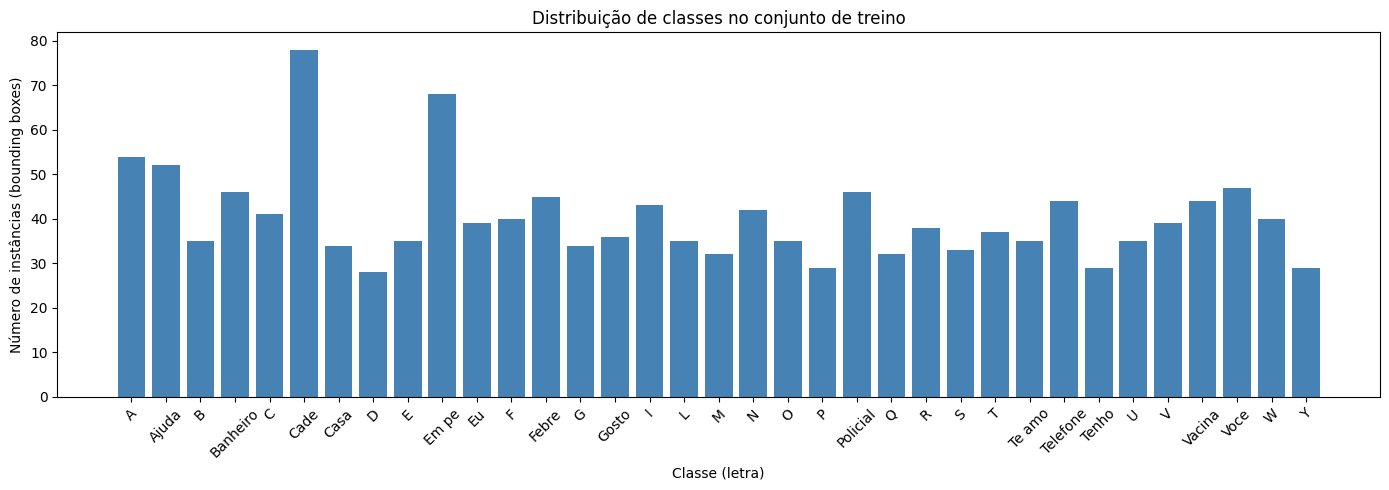


Total de instâncias: 1409
Classe com mais exemplos: Cade (78)
Classe com menos exemplos: D (28)
Razão de desbalanceamento (max/min): 2.79x


In [5]:
# Distribuição de classes — conta instâncias (não imagens) nos arquivos de label do treino
train_labels_dir = os.path.join(DATASET_PATH, 'train', 'labels')

contagem = Counter()
for label_file in glob.glob(os.path.join(train_labels_dir, '*.txt')):
    with open(label_file) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_id = int(parts[0])
                contagem[nomes_classes[class_id]] += 1

classes_ord = sorted(contagem.keys())
valores = [contagem[c] for c in classes_ord]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(classes_ord, valores, color='steelblue')
ax.set_xlabel('Classe (letra)')
ax.set_ylabel('Número de instâncias (bounding boxes)')
ax.set_title('Distribuição de classes no conjunto de treino')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal de instâncias: {sum(valores)}')
if valores:
    print(f'Classe com mais exemplos: {max(contagem, key=contagem.get)} ({max(valores)})')
    print(f'Classe com menos exemplos: {min(contagem, key=contagem.get)} ({min(valores)})')
    print(f'Razão de desbalanceamento (max/min): {max(valores) / max(min(valores), 1):.2f}x')

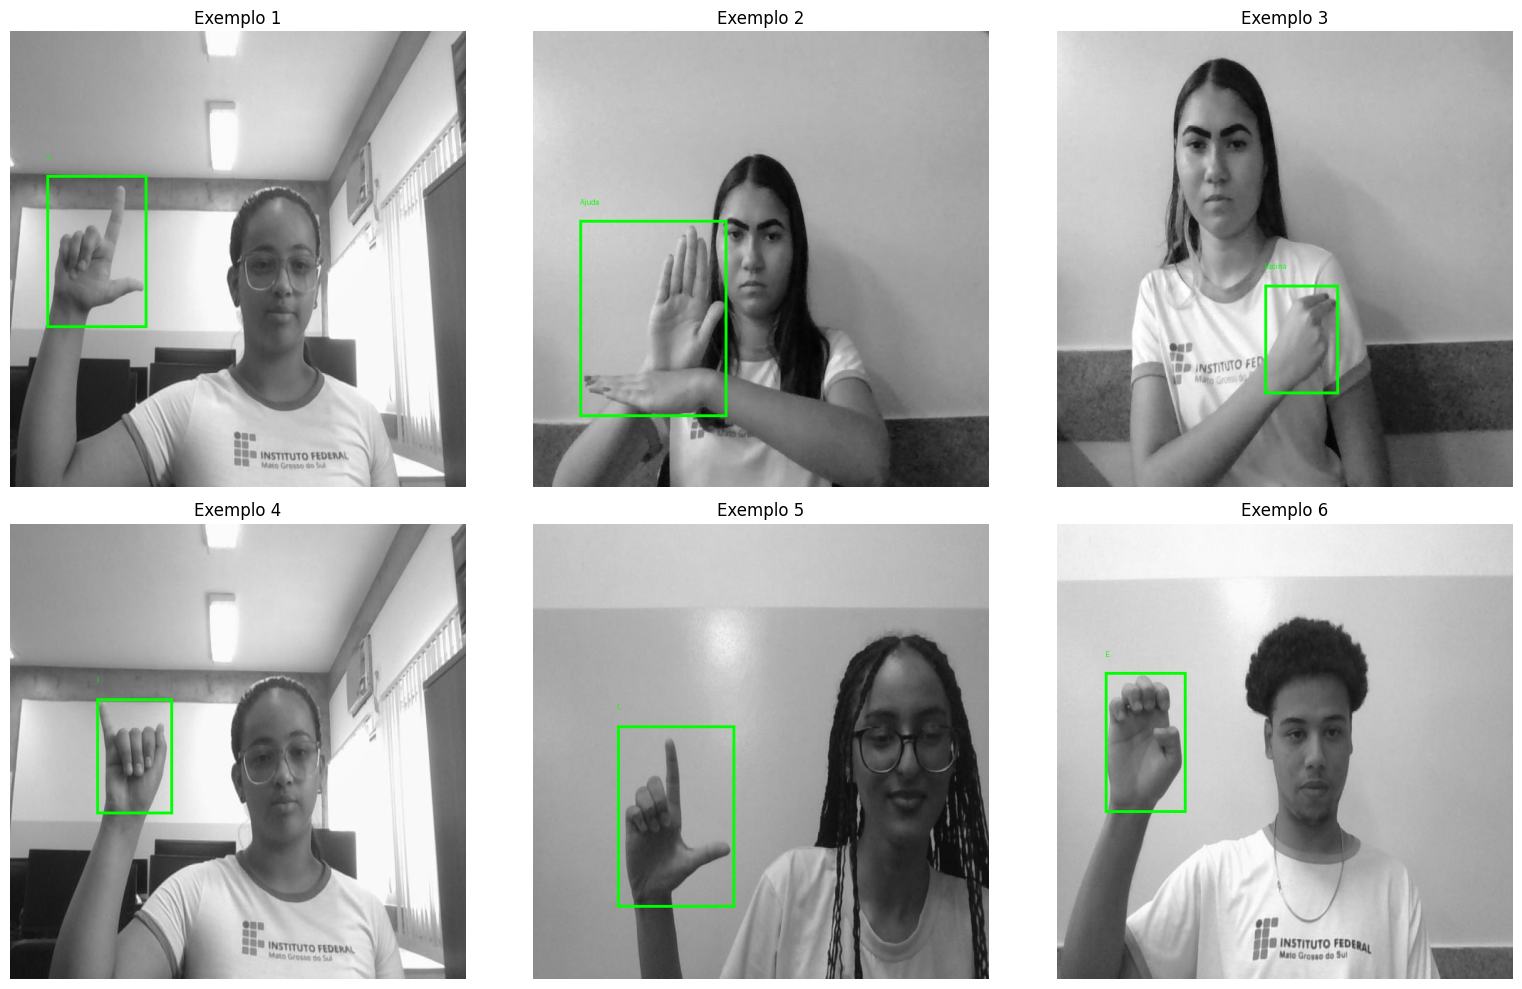

In [6]:
# Visualizar imagens do conjunto de teste com bounding boxes ground-truth
test_img_dir = os.path.join(DATASET_PATH, 'test', 'images')
test_label_dir = os.path.join(DATASET_PATH, 'test', 'labels')

image_files = [f for f in os.listdir(test_img_dir)
               if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
sample_images = random.sample(image_files, min(6, len(image_files)))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, img_file in enumerate(sample_images):
    img_path = os.path.join(test_img_dir, img_file)
    label_path = os.path.join(test_label_dir, os.path.splitext(img_file)[0] + '.txt')

    img = Image.open(img_path).convert('RGB')
    draw = ImageDraw.Draw(img)
    w, h = img.size
    font_size = max(int(w * 0.05), 14)

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                class_id = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:5])
                x1 = (xc - bw/2) * w
                y1 = (yc - bh/2) * h
                x2 = (xc + bw/2) * w
                y2 = (yc + bh/2) * h
                draw.rectangle([x1, y1, x2, y2], outline='lime', width=4)
                classe = nomes_classes[class_id] if class_id < len(nomes_classes) else str(class_id)
                draw.text((x1, max(0, y1 - font_size)), classe, fill='lime')

    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'Exemplo {i+1}')

plt.tight_layout()
plt.savefig('test_samples.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Treinamento do Modelo YOLO (Detection)

### Variantes disponíveis

| Variante | Parâmetros | Quando usar |
|---|---|---|
| `yolov8n.pt` (nano) | 3.2M | Testes rápidos, GPU fraca |
| `yolov8s.pt` (small) | 11.2M | Bom equilíbrio velocidade/qualidade |
| `yolov8m.pt` (medium) | 25.9M | **Recomendado** para este projeto na T4 |
| `yolov8l.pt` (large) | 43.7M | Se houver GPU robusta |
| `yolov8x.pt` (xlarge) | 68.2M | Máxima qualidade |

### Hiperparâmetros principais
- `epochs`: 50–100 (começar com 50 e monitorar overfitting)
- `batch`: 16 para T4 com imgsz=640
- `imgsz`: 640 (padrão YOLO)
- `patience`: 15 (early stopping)

Documentação: https://docs.ultralytics.com/pt/modes/train/

In [7]:
# Liberar memória da GPU antes do treino
import gc
import torch
gc.collect()
torch.cuda.empty_cache()

In [8]:
from ultralytics import YOLO

# Modelo pré-treinado YOLOv8m (detection)
model = YOLO('yolov8m.pt')

# Treinamento
results_train = model.train(
    data=os.path.join(DATASET_PATH, 'data.yaml'),
    epochs=50,
    imgsz=640,
    batch=16,
    patience=15,
    name='libras_yolov8m',
    project='runs/detect',
    exist_ok=True,
    save=True,
    plots=True,
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/projeto-libras-20/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=libras_yolov8m, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

### Visualização dos gráficos de treinamento

Diretório do treino: /content/runs/detect/runs/detect/libras_yolov8m


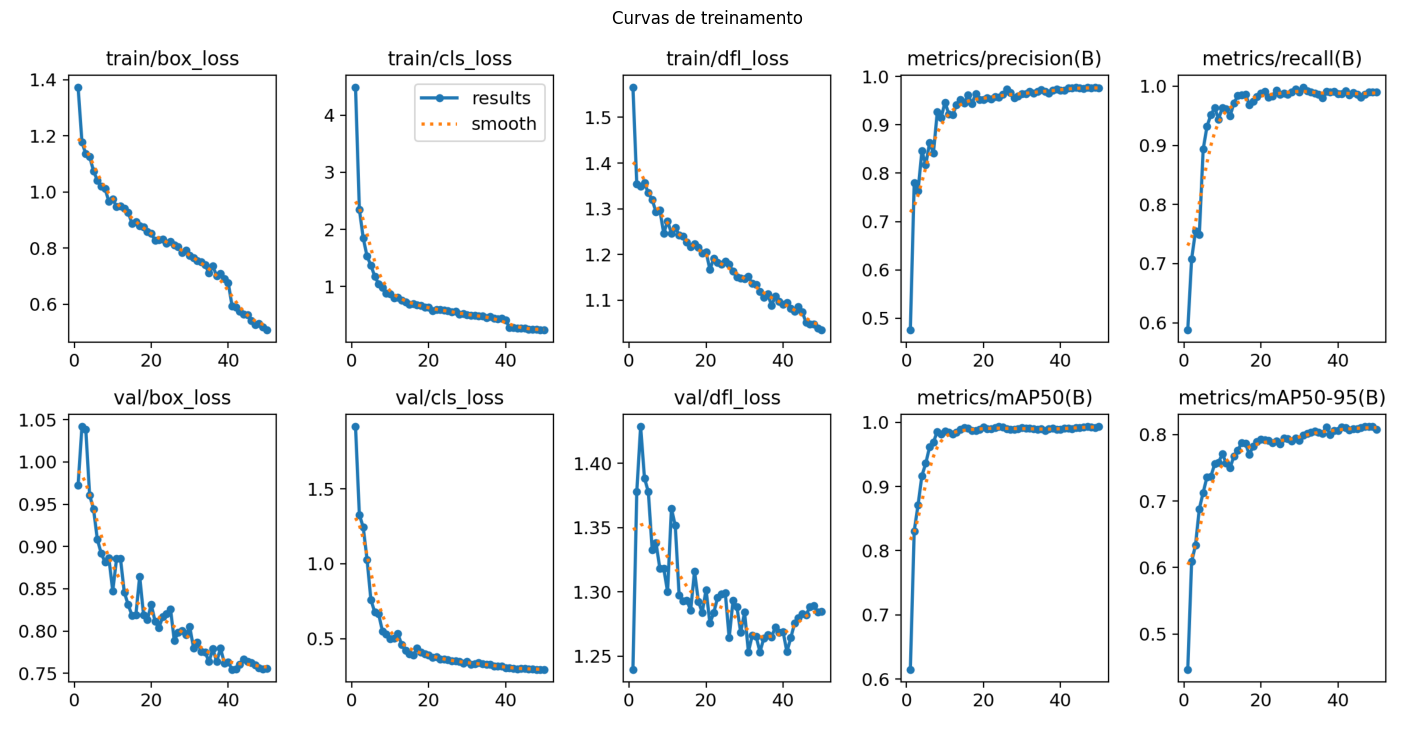

In [9]:
train_save_dir = str(model.trainer.save_dir) if hasattr(model, 'trainer') else 'runs/detect/libras_yolov8m'
print(f'Diretório do treino: {train_save_dir}')

results_img = os.path.join(train_save_dir, 'results.png')
if os.path.exists(results_img):
    img = Image.open(results_img)
    plt.figure(figsize=(18, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Curvas de treinamento')
    plt.show()

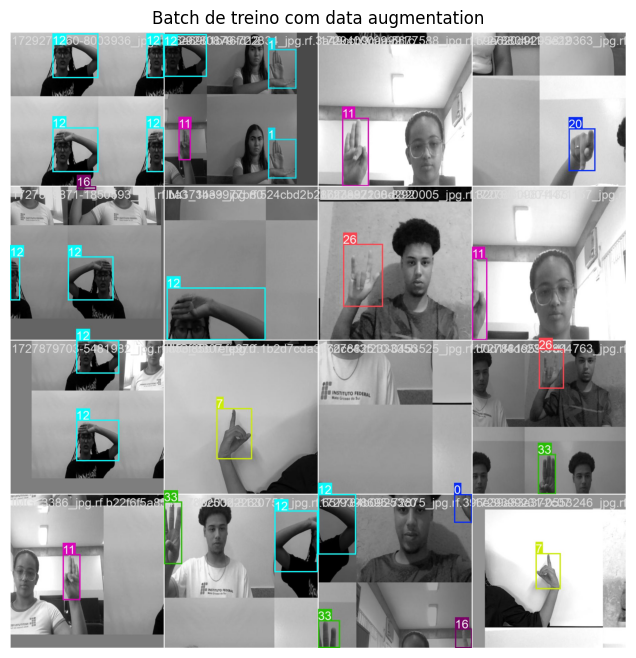

In [10]:
# Batch de treino com augmentation
aug_img = os.path.join(train_save_dir, 'train_batch0.jpg')
if os.path.exists(aug_img):
    img = Image.open(aug_img)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Batch de treino com data augmentation')
    plt.show()

---
## 5. Avaliação no Conjunto de Teste

Métricas para detecção:
- **mAP@0.5**: precisão média com IoU ≥ 0.5
- **mAP@0.5:0.95**: média do mAP para IoU de 0.5 a 0.95 (mais rigoroso)
- **Precisão**: TP / (TP + FP)
- **Revocação**: TP / (TP + FN)
- **Matriz de confusão**: revela quais letras o modelo confunde

In [11]:
# Avaliação no conjunto de TESTE
results_val = model.val(
    data=os.path.join(DATASET_PATH, 'data.yaml'),
    split='test',
    plots=True,
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,860,025 parameters, 0 gradients, 78.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 16.3±7.8 MB/s, size: 28.2 KB)
val: Scanning /content/projeto-libras-20/test/labels... 195 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 195/195 968.5it/s 0.2s
val: New cache created: /content/projeto-libras-20/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.1it/s 6.2s
                   all        195        202      0.966      0.978      0.987      0.826
                     A          7          7      0.986          1      0.995      0.784
                 Ajuda          8          8      0.986          1      0.995      0.871
                     B          5          5      0.973          1      0.995      0.896
              Banheiro          7          7      0.989          1  

In [12]:
metrics = results_val.results_dict
print('=' * 50)
print('📊 MÉTRICAS GLOBAIS NO CONJUNTO DE TESTE')
print('=' * 50)
print(f'Precisão média:   {metrics.get("metrics/precision(B)", 0):.4f}')
print(f'Revocação média:  {metrics.get("metrics/recall(B)", 0):.4f}')
print(f'mAP@0.5:          {metrics.get("metrics/mAP50(B)", 0):.4f}')
print(f'mAP@0.5:0.95:     {metrics.get("metrics/mAP50-95(B)", 0):.4f}')
print('=' * 50)

📊 MÉTRICAS GLOBAIS NO CONJUNTO DE TESTE
Precisão média:   0.9658
Revocação média:  0.9780
mAP@0.5:          0.9869
mAP@0.5:0.95:     0.8258


In [13]:
# Métricas por classe
import pandas as pd

per_class = []
for i, nome in enumerate(nomes_classes):
    try:
        p = float(results_val.box.p[i]) if i < len(results_val.box.p) else None
        r = float(results_val.box.r[i]) if i < len(results_val.box.r) else None
        map50 = float(results_val.box.ap50[i]) if i < len(results_val.box.ap50) else None
        map5095 = float(results_val.box.ap[i]) if i < len(results_val.box.ap) else None
        per_class.append({
            'Classe': nome,
            'Precisão': round(p, 4) if p is not None else None,
            'Recall': round(r, 4) if r is not None else None,
            'mAP@0.5': round(map50, 4) if map50 is not None else None,
            'mAP@0.5:0.95': round(map5095, 4) if map5095 is not None else None,
        })
    except (IndexError, AttributeError):
        continue

df_metricas = pd.DataFrame(per_class).sort_values('mAP@0.5', ascending=False)
display(df_metricas)
df_metricas.to_csv('metricas_por_classe.csv', index=False)

,Classe,Precisão,Recall,mAP@0.5,mAP@0.5:0.95
0,A,0.9858,1.0000,0.9950,0.7836
1,Ajuda,0.9861,1.0000,0.9950,0.8708
2,B,0.9730,1.0000,0.9950,0.8963
3,Banheiro,0.9894,1.0000,0.9950,0.5637
4,C,0.9798,1.0000,0.9950,0.8661
5,Cade,1.0000,0.9203,0.9950,0.6412
6,Casa,0.9782,1.0000,0.9950,0.8994
7,D,0.7430,1.0000,0.9950,0.9510
8,E,0.9700,1.0000,0.9950,0.9153
9,Em pe,0.9903,1.0000,0.9950,0.7775


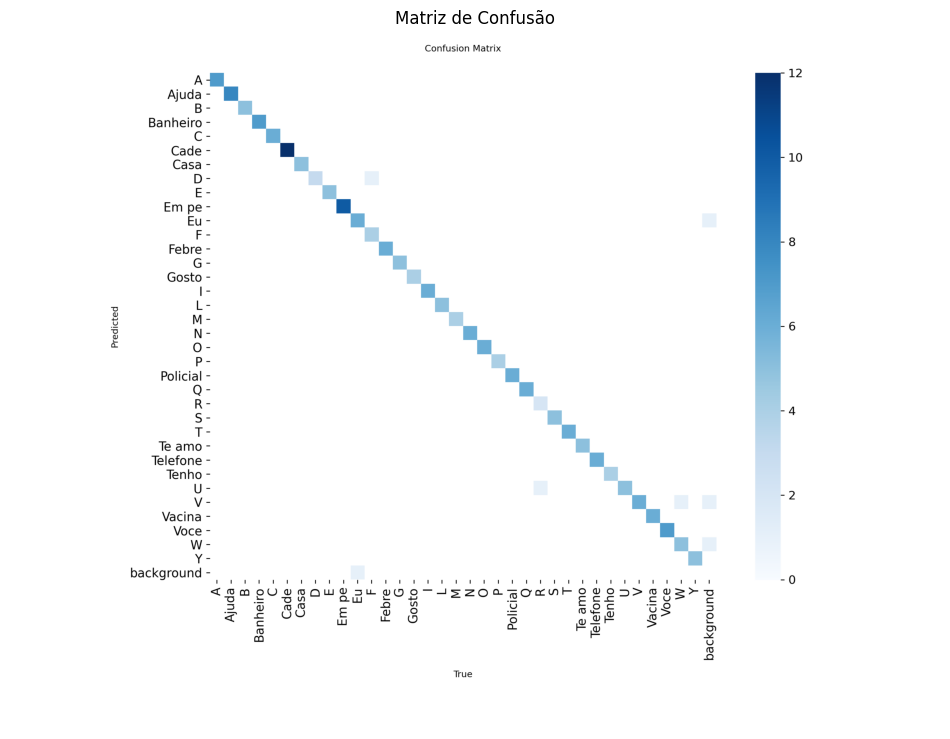

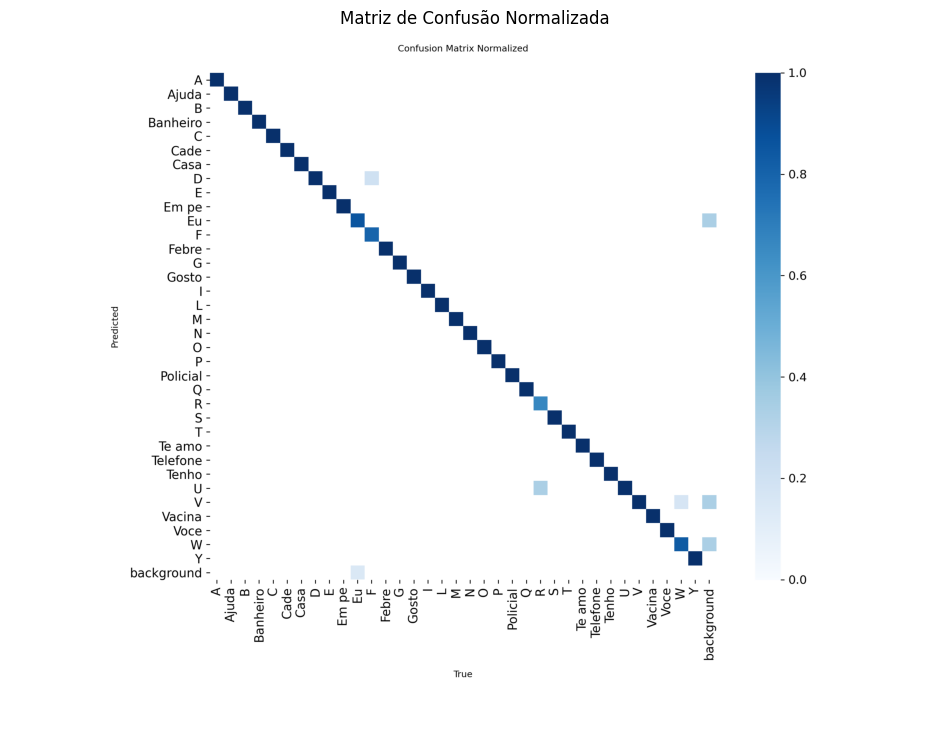

In [14]:
# Matriz de confusão e curvas geradas pelo Ultralytics
val_save_dir = str(results_val.save_dir) if hasattr(results_val, 'save_dir') else 'runs/detect/val'

for arq, titulo in [
    ('confusion_matrix.png', 'Matriz de Confusão'),
    ('confusion_matrix_normalized.png', 'Matriz de Confusão Normalizada'),
    ('PR_curve.png', 'Curva Precisão × Revocação'),
    ('F1_curve.png', 'Curva F1 × Confiança'),
]:
    path = os.path.join(val_save_dir, arq)
    if os.path.exists(path):
        img = Image.open(path)
        plt.figure(figsize=(12, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.title(titulo)
        plt.show()

---
## 6. Inferência em Imagens Reais

### Dicas para boas fotos
- Fundo neutro (parede branca, lousa)
- Iluminação frontal uniforme, sem sombras fortes
- Mão centralizada, visível por inteiro
- Distância de 30–80 cm da câmera
- Resolução mínima 640×640 (qualquer celular moderno serve)

In [21]:
# Upload de imagens capturadas pela equipe (no Colab)
from google.colab import files
uploaded = files.upload()
user_images = [f'/content/{name}' for name in uploaded.keys()]
print(f'Imagens carregadas: {user_images}')

Saving WhatsApp Image 2026-06-06 at 13.01.19.jpeg to WhatsApp Image 2026-06-06 at 13.01.19.jpeg
Imagens carregadas: ['/content/WhatsApp Image 2026-06-06 at 13.01.19.jpeg']


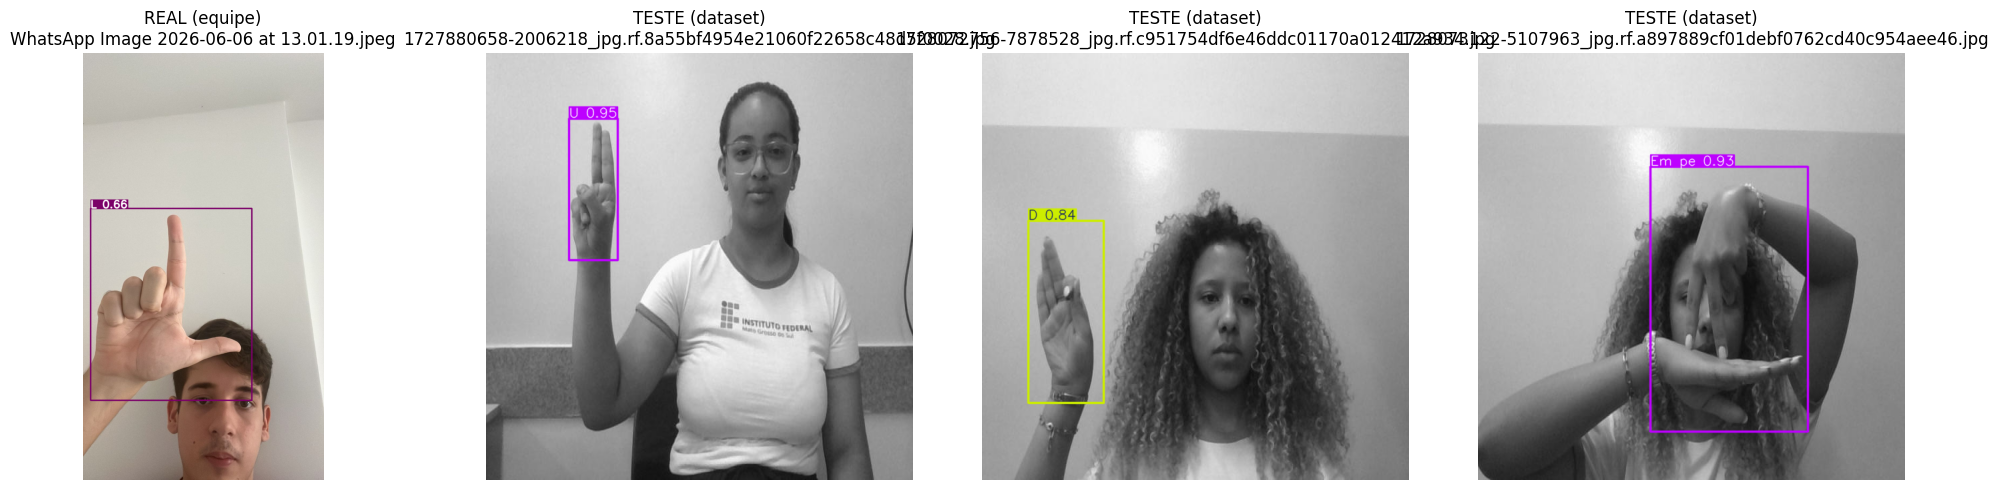

In [22]:
# Inferência nas imagens reais + amostras do conjunto de teste
amostras_teste = random.sample(
    glob.glob(os.path.join(test_img_dir, '*.jpg')),
    min(3, len(glob.glob(os.path.join(test_img_dir, '*.jpg'))))
)

todas = user_images + amostras_teste
preds = [model.predict(img, conf=0.25, verbose=False)[0] for img in todas]

n = len(preds)
cols = min(4, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
axes = axes.flatten() if rows * cols > 1 else [axes]

for i, pred in enumerate(preds):
    img_bgr = pred.plot()
    img_rgb = img_bgr[:, :, ::-1]
    origem = 'REAL (equipe)' if i < len(user_images) else 'TESTE (dataset)'
    axes[i].imshow(img_rgb)
    axes[i].set_title(f'{origem}\n{os.path.basename(todas[i])}')
    axes[i].axis('off')

for j in range(len(preds), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('predicoes_reais.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Detalhes das detecções: classe, confiança, coordenadas
print('=' * 70)
print('DETALHES DAS DETECÇÕES')
print('=' * 70)
for i, pred in enumerate(preds):
    origem = 'REAL' if i < len(user_images) else 'TESTE'
    print(f'\n[{origem}] {os.path.basename(todas[i])}')
    if len(pred.boxes) == 0:
        print('   ⚠️ Nenhuma detecção')
        continue
    for box in pred.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        xyxy = box.xyxy[0].tolist()
        print(f'   → {nomes_classes[cls_id]:>3s}  conf={conf:.3f}  bbox=[{xyxy[0]:.0f}, {xyxy[1]:.0f}, {xyxy[2]:.0f}, {xyxy[3]:.0f}]')

DETALHES DAS DETECÇÕES

[REAL] WhatsApp Image 2026-06-06 at 13.01.19.jpeg
   →   L  conf=0.664  bbox=[29, 582, 630, 1302]

[TESTE] 1727880658-2006218_jpg.rf.8a55bf4954e21060f22658c48d5f0028.jpg
   →   U  conf=0.952  bbox=[124, 99, 198, 310]

[TESTE] 1728072756-7878528_jpg.rf.c951754df6e46ddc01170a012412a934.jpg
   →   D  conf=0.836  bbox=[70, 252, 183, 525]

[TESTE] 1728073122-5107963_jpg.rf.a897889cf01debf0762cd40c954aee46.jpg
   → Em pe  conf=0.929  bbox=[259, 171, 494, 567]


---
## 7. Exportação dos Artefatos

In [24]:
import shutil

os.makedirs('/content/artefatos', exist_ok=True)

# Modelo treinado
best_pt = os.path.join(train_save_dir, 'weights', 'best.pt')
if os.path.exists(best_pt):
    shutil.copy(best_pt, '/content/artefatos/best.pt')

# Artefatos do treino
for arq in ['results.png', 'results.csv', 'confusion_matrix.png',
            'confusion_matrix_normalized.png', 'PR_curve.png',
            'F1_curve.png', 'P_curve.png', 'R_curve.png',
            'train_batch0.jpg', 'labels.jpg']:
    src = os.path.join(train_save_dir, arq)
    if os.path.exists(src):
        shutil.copy(src, f'/content/artefatos/{arq}')

# Artefatos da validação no test
for arq in ['confusion_matrix.png', 'confusion_matrix_normalized.png',
            'PR_curve.png', 'F1_curve.png']:
    src = os.path.join(val_save_dir, arq)
    dst = f'/content/artefatos/test_{arq}'
    if os.path.exists(src):
        shutil.copy(src, dst)

# Artefatos gerados pelo notebook
for arq in ['metricas_por_classe.csv', 'class_distribution.png',
            'test_samples.png', 'predicoes_reais.png']:
    if os.path.exists(f'/content/{arq}'):
        shutil.copy(f'/content/{arq}', f'/content/artefatos/{arq}')

shutil.make_archive('/content/artefatos_libras', 'zip', '/content/artefatos')
print('✅ Artefatos prontos em /content/artefatos_libras.zip')
print('Faça o download e descompacte na pasta results/ do repositório.')

files.download('/content/artefatos_libras.zip')

✅ Artefatos prontos em /content/artefatos_libras.zip
Faça o download e descompacte na pasta results/ do repositório.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 8. Conclusão

Após o treinamento e avaliação:

1. Atualize o **README.md** do repositório com as métricas finais (mAP, precisão, recall).
2. Preencha o **relatório técnico** (`report/relatorio_template.md`) com análise crítica:
   - Quais letras o modelo confunde mais? (matriz de confusão revela pares como M/N, U/V, A/S)
   - O modelo generalizou para suas fotos reais? Se não, por quê?
   - O que faria diferente numa próxima iteração?

### Próximos passos sugeridos
- Testar YOLOv8l ou YOLOv11 para comparar desempenho
- Avaliar em vídeo (detecção contínua, FPS)
- Tratar sinais dinâmicos (H, J, K, X, Z) com modelo temporal
- Combinar com landmarks da mão (MediaPipe Hands) para features extras